In [1]:
import pandas as pd
from repositories.transaction_repo import TransactionRepository
from repositories.category_repo import CategoryRepository
from database.session_manager import get_db_session


In [32]:
def get_repos():
    return {
        "transaction": TransactionRepository(),
        "category": CategoryRepository()
}

repositories = get_repos()

try:
    with get_db_session() as db:
        transactions = repositories['transaction'].get_transactions_with_categories(db, limit=100000)

        if transactions:
            data = []
            for t in transactions:
                data.append({
                    "Date": t.date.strftime("%d-%m-%Y"),
                    "Amount": f"{t.amount:,.2f} ₽",
                    "Category": t.category_rel.name_category if t.category_rel else "N/A",
                    "Comment": t.comment or ""
                })
                            
            df = pd.DataFrame(data)

except Exception as e:
            print(e)


2026-08-05 16:52:14,226 DEBUG sqlalchemy.pool.impl.QueuePool Connection <connection object at 0x0000021E14DD86A0; dsn: 'user=kart_nuar password=xxx dbname=nour-tech host=192.168.1.79 port=1612', closed: 0> checked out from pool
2026-08-05 16:52:14,228 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-05 16:52:14,229 INFO sqlalchemy.engine.Engine SELECT transactions.id, transactions.date, transactions.amount, transactions.comment, transactions.category_id, categories_1.id AS id_1, categories_1.name_category, categories_1.description, categories_1.type_category 
FROM transactions LEFT OUTER JOIN categories AS categories_1 ON categories_1.id = transactions.category_id 
 LIMIT %(param_1)s OFFSET %(param_2)s
2026-08-05 16:52:14,230 INFO sqlalchemy.engine.Engine [cached since 951s ago] {'param_1': 100000, 'param_2': 0}
2026-08-05 16:52:14,597 INFO sqlalchemy.engine.Engine COMMIT
2026-08-05 16:52:14,600 DEBUG sqlalchemy.pool.impl.QueuePool Connection <connection object at 0x0000021E14DD8

In [33]:
df

,Date,Amount,Category,Comment
0,04-07-2026,500.00 ₽,Питание,Тестовая запись
1,15-11-2025,"2,456.00 ₽",Питание,фастфуд
2,15-11-2025,"1,283.00 ₽",Питание,лавка
3,20-02-2026,99.00 ₽,Подписки,сбер
4,13-03-2026,"2,381.00 ₽",Питание,самокат
...,...,...,...,...
895,31-05-2026,533.00 ₽,Питание,кб
896,31-05-2026,"1,368.00 ₽",Кафе и рестораны,деливери
897,31-05-2026,"1,152.00 ₽",Питание,самокат
898,30-05-2026,"1,921.00 ₽",Кафе и рестораны,деливери


In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
df[0:1]['Amount']

0    500.00 ₽
Name: Amount, dtype: str

In [38]:
df_change = df.copy()

In [44]:
df_change['Amount'] = df_change['Amount'].apply(lambda x: x.split(' ')[0])
df_change['Amount'] = df_change['Amount'].apply(lambda x: x.split('.')[0])
df_change['Amount'] = df_change['Amount'].apply(lambda x: ''.join(x.split(',')))
df_change['Amount']

0       500
1      2456
2      1283
3        99
4      2381
       ... 
895     533
896    1368
897    1152
898    1921
899     230
Name: Amount, Length: 900, dtype: str

In [46]:
df_change['Amount'] = pd.to_numeric(df_change['Amount'], errors='coerce', downcast='integer')
df_change

,Date,Amount,Category,Comment
0,04-07-2026,500,Питание,Тестовая запись
1,15-11-2025,2456,Питание,фастфуд
2,15-11-2025,1283,Питание,лавка
3,20-02-2026,99,Подписки,сбер
4,13-03-2026,2381,Питание,самокат
...,...,...,...,...
895,31-05-2026,533,Питание,кб
896,31-05-2026,1368,Кафе и рестораны,деливери
897,31-05-2026,1152,Питание,самокат
898,30-05-2026,1921,Кафе и рестораны,деливери


In [48]:
df

,Date,Amount,Category,Comment
0,04-07-2026,500.00 ₽,Питание,Тестовая запись
1,15-11-2025,"2,456.00 ₽",Питание,фастфуд
2,15-11-2025,"1,283.00 ₽",Питание,лавка
3,20-02-2026,99.00 ₽,Подписки,сбер
4,13-03-2026,"2,381.00 ₽",Питание,самокат
...,...,...,...,...
895,31-05-2026,533.00 ₽,Питание,кб
896,31-05-2026,"1,368.00 ₽",Кафе и рестораны,деливери
897,31-05-2026,"1,152.00 ₽",Питание,самокат
898,30-05-2026,"1,921.00 ₽",Кафе и рестораны,деливери


In [49]:
df_change['Date'] = pd.to_datetime(df_change['Date'], format='%d-%m-%Y')
df_change

,Date,Amount,Category,Comment
0,2026-07-04,500,Питание,Тестовая запись
1,2025-11-15,2456,Питание,фастфуд
2,2025-11-15,1283,Питание,лавка
3,2026-02-20,99,Подписки,сбер
4,2026-03-13,2381,Питание,самокат
...,...,...,...,...
895,2026-05-31,533,Питание,кб
896,2026-05-31,1368,Кафе и рестораны,деливери
897,2026-05-31,1152,Питание,самокат
898,2026-05-30,1921,Кафе и рестораны,деливери


In [51]:
df_change.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      900 non-null    datetime64[us]
 1   Amount    900 non-null    int32         
 2   Category  900 non-null    str           
 3   Comment   900 non-null    str           
dtypes: datetime64[us](1), int32(1), str(2)
memory usage: 52.0 KB


(0.0, 3000.0)

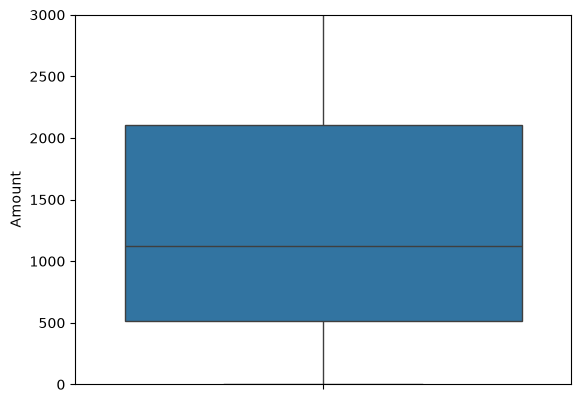

In [69]:
sns.boxplot(data=df_change, y='Amount')
plt.ylim(0, 3000)

In [58]:
df_change['Category'].values.unique()

<ArrowStringArray>
[                         'Питание',                         'Подписки',
           'Общественный транспорт',                 'Кафе и рестораны',
                          'Питомец', 'Развлечения (в т.ч. в интернете)',
                         'Здоровье',                          'Клининг',
                 'Связь и интернет',                            'Жильё',
    'Нежелательные траты + кредиты',                    'Красота и быт',
           'Непредвиденные покупки',       'Одежда, обувь и аксессуары',
                         'Психолог']
Length: 15, dtype: str

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Питание'),
  Text(1, 0, 'Подписки'),
  Text(2, 0, 'Общественный транспорт'),
  Text(3, 0, 'Кафе и рестораны'),
  Text(4, 0, 'Питомец'),
  Text(5, 0, 'Развлечения (в т.ч. в интернете)'),
  Text(6, 0, 'Здоровье'),
  Text(7, 0, 'Клининг'),
  Text(8, 0, 'Связь и интернет'),
  Text(9, 0, 'Жильё'),
  Text(10, 0, 'Нежелательные траты + кредиты'),
  Text(11, 0, 'Красота и быт'),
  Text(12, 0, 'Непредвиденные покупки'),
  Text(13, 0, 'Одежда, обувь и аксессуары'),
  Text(14, 0, 'Психолог')])

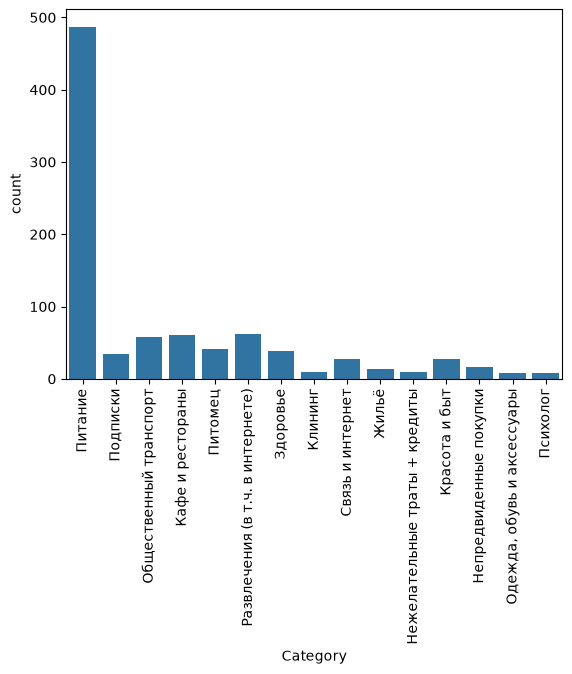

In [62]:
sns.countplot(data=df_change, x='Category')
plt.xticks(rotation=90)

(0.0, 2000.0)

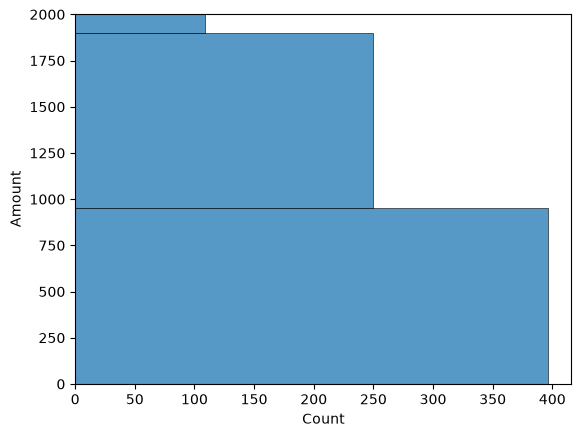

In [71]:
sns.histplot(data=df_change, y='Amount')
#plt.xticks(rotation=90)
plt.ylim(0, 2000)